# Laserfarm on Spider tutorial

Welcome to the tutorial for running the [Laserfarm workflow](https://laserfarm.readthedocs.io/en/latest/index.html) using [SLURM](https://slurm.schedmd.com/documentation.html) on [Spider](https://doc.spider.surfsara.nl/en/latest/) hosted by [SURF](https://www.surf.nl/en). In this tutorial, we will demonstrate how to access the Spider infrastructure and set up JupyterLab. Then, we will demonstrate how to run the Laserfarm workflow by assigning a cluster with several workers and running the process in parallel. 

For getting started with Spider, you are encouraged to follow the official [documentation](https://doc.spider.surfsara.nl/en/latest/Pages/getting_started.html) of Spider.

For the participants of the MAMBO workshop, you should have already received an email about your account for signing in to Spider (in the email address you used for workshop registration). Follow the instructions from the email, where you will find your username, password setting (should be updated within 12 hours after you receive the email), and the hostname. You can then use that account to log in [SURF CUA portal](https://portal.cua.surf.nl/home/). Please follow the official [documentation](https://doc.spider.surfsara.nl/en/latest/Pages/getting_started.html) on getting started on Spider provided by SURF. We only show several essential steps for getting access to Spider below.

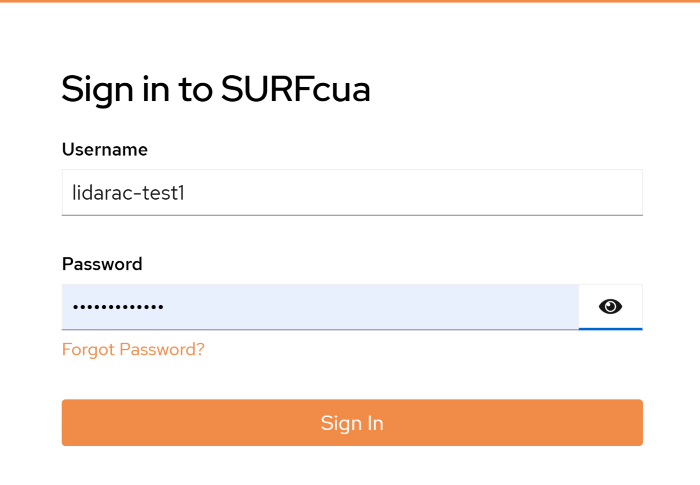

Remeber to agree to the "Usage Agreement" before you continue. In order to generate your SSH key. You can simply go to your terminal and type the following command: `ssh-keygen`. You can leave the output file name blank for the default file name, or type a variation of `~/.ssh/my_chosen_name`. You then will be asked to choose a passphrase. After that, you should see something similar to:

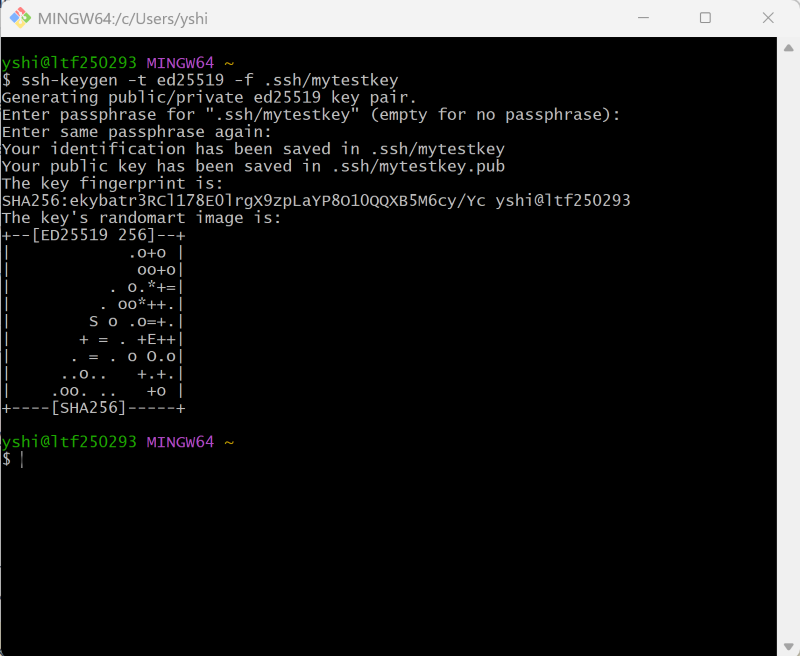

Then you should be able to find your SSH keys under folder: C:\Users\yshi[your user name]\\.ssh, where both a private and public keys are stored. Copy the text from the .pub file to the CUA User Portal under the SSH keys tab, and enter your password. The click “Add SSH key”.

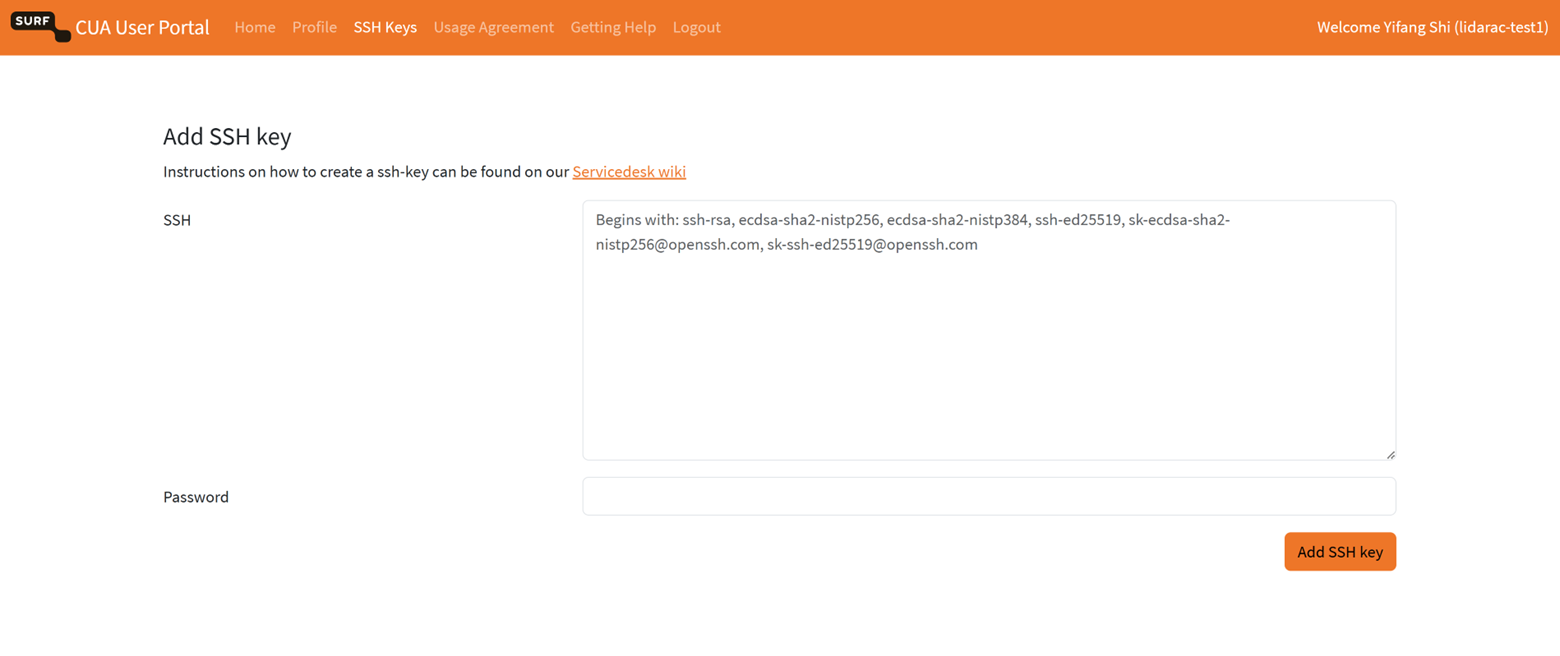

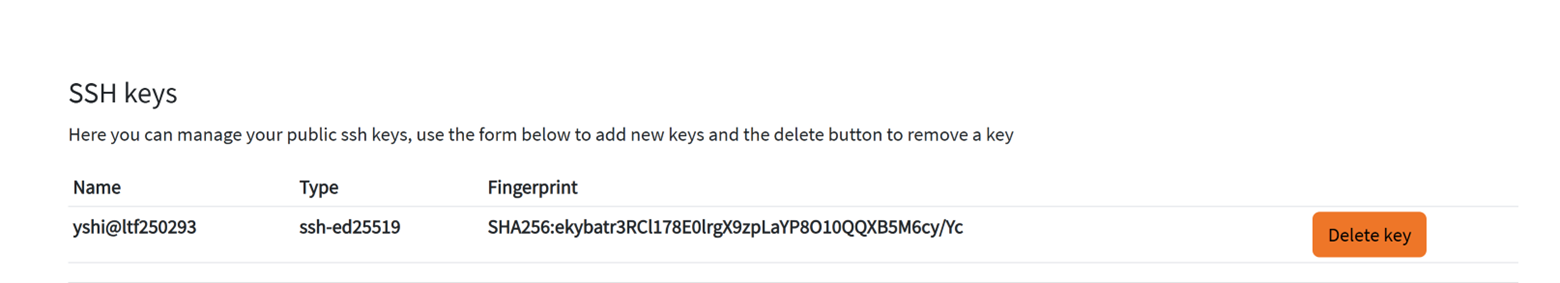

NOTE: Please give your keys and account some time to sync after uploading your public key in the portal. After that you can login to Spider with your SSH keys from your laptop (or other computer where your SSH key was generated/transferred). 

## Login to Spider

After adding your ssh, you can login to Spider via a terminal (e.g. Git Bash) with the following command:

`ssh [USERNAME]@spider.surf.nl`

You may enter your password if required. Note: In case you have multiple keys in your .ssh/ folder, you would need to specify the key that marches the .pub file you uploaded to the SURF CUA portal. For instance: `ssh -i ~/.ssh/mytestkey lidarac-test1@spider.surfsara.nl`. Once you see the following notice, congrats! You've just logged in to Spider.

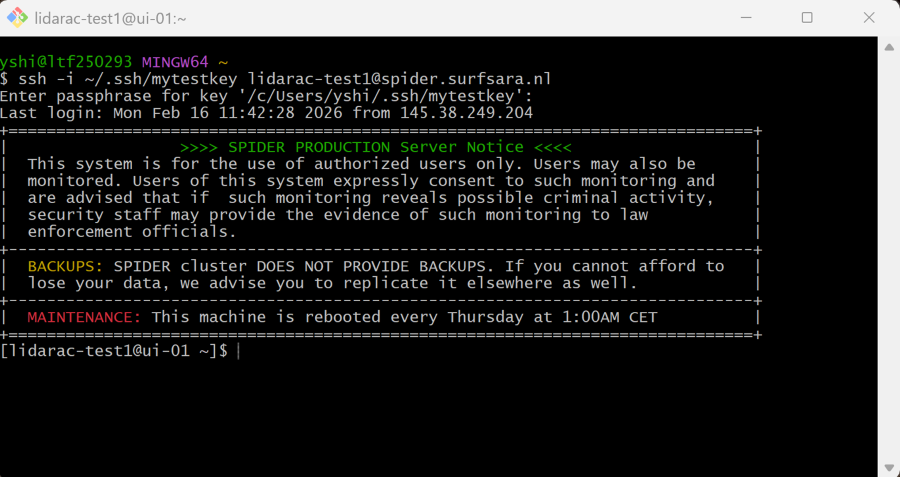

Now you are at the `home` folder of the project space. 

## Set up JupyterLab using a container wrapper for Spider

Clone the `AHN4_on_Spider` repository in your home directory by typing in:  

In [ ]:
git clone https://github.com/ShiYifang/AHN4_on_Spider.git

Change the directory to the `AHN4_on_Spider`:  

`cd AHN4_on_Spider`

In this directory, you can find [environment file](environment.yml) that lists all the dependencies of Laserfarm workflow, the [job script](Scripts/jupyterdask-spider.slurm) that defines the cluster (e.g. number of cores, memory per worker) you are going to set up on SLURM, and the [Jupyter Notebooks](Scripts/Notebooks) of Laserfarm workflow that are used for processing country-wide ALS point cloud into GeoTIFF raster layers.

You can check the `environment.yml` file and the job script file (`Scripts/jupyterdask-spider.slurm`) by typing the following command in your terminal:

`cat environment.yml`

`cat Script/jupyterdask-spider.slurm`


Now you can submit a job to launch your JupyterLab on Spider. Typing:

`sbatch  jupyterdask-spider.slurm`

Then you should be able to find the `.out` file under folder `.jupyterdask`

`cd .jupyterdask`  

`ls`

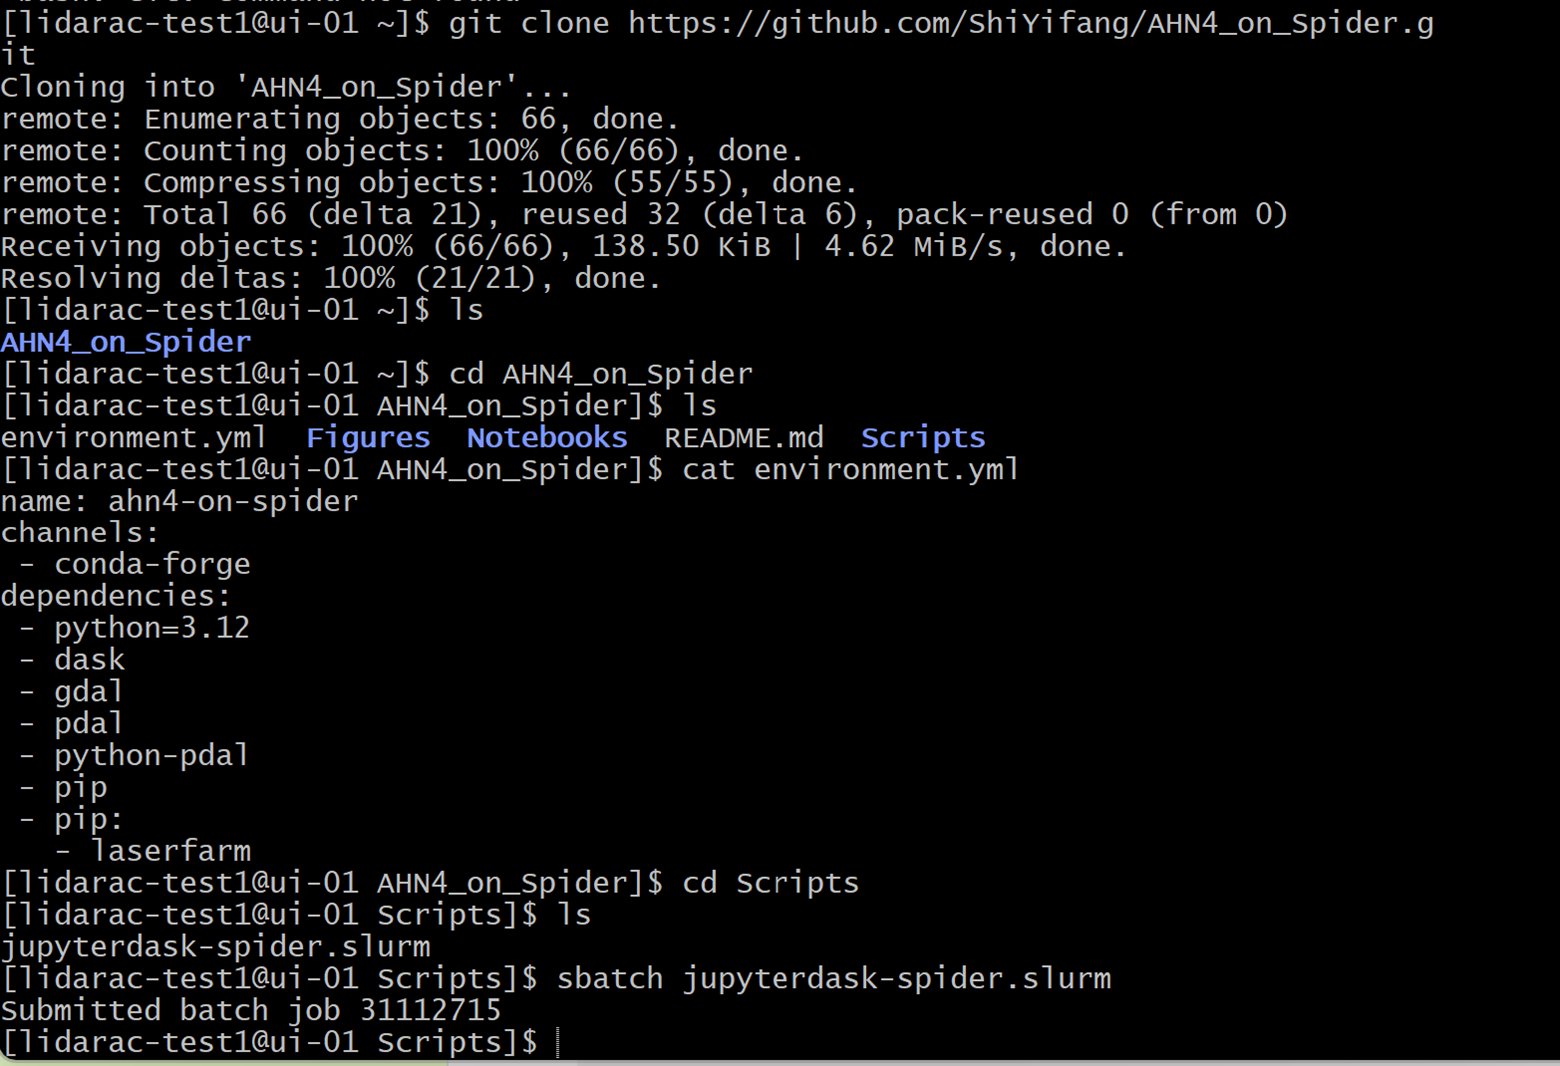

You can check the status of your submitted and not completed job(s) using:

`squeue -u lidarac-test1[YOUR USER NAME]` or `squeue --job [JOBID]`

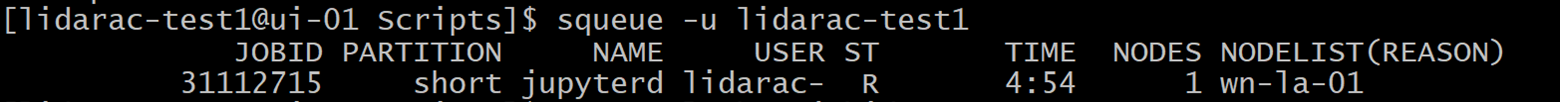

Check your job output:

`cat jupyter-spider.slurm-[JOBID].out`

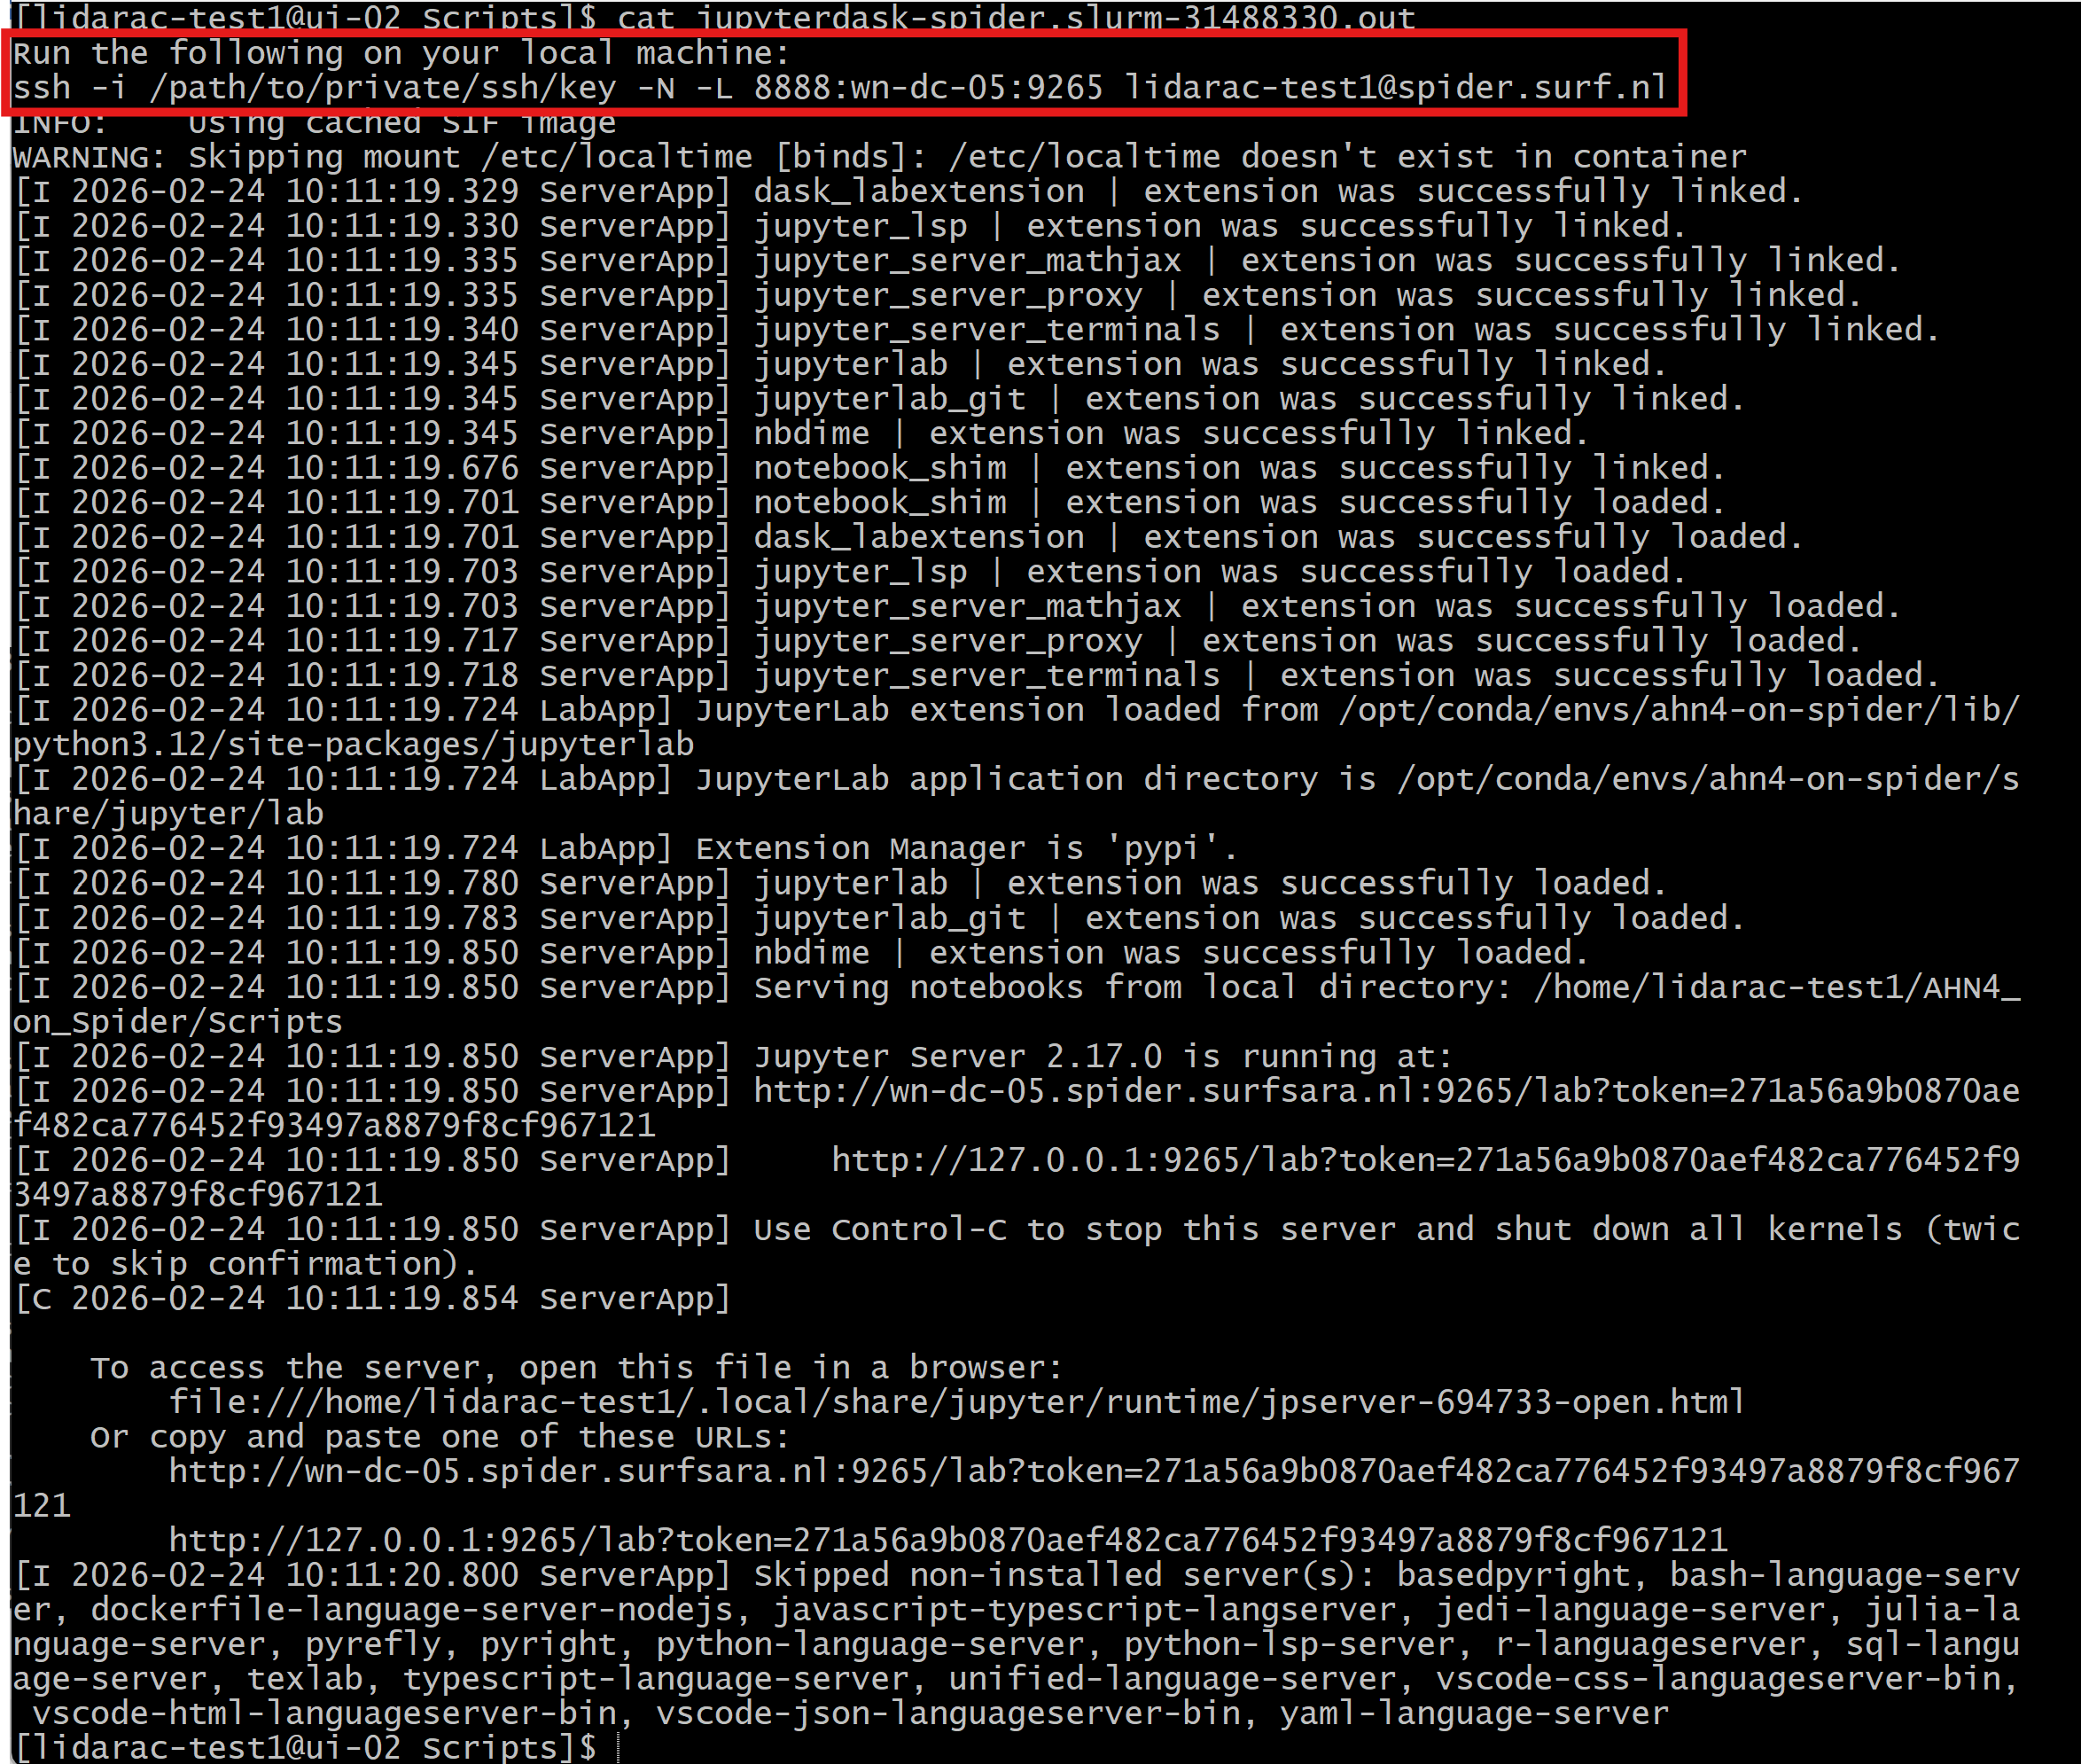

Run the first ssh line of the `.out` file in a new terminal. You may need to specify the location of your private key. Specify your passphrase. 

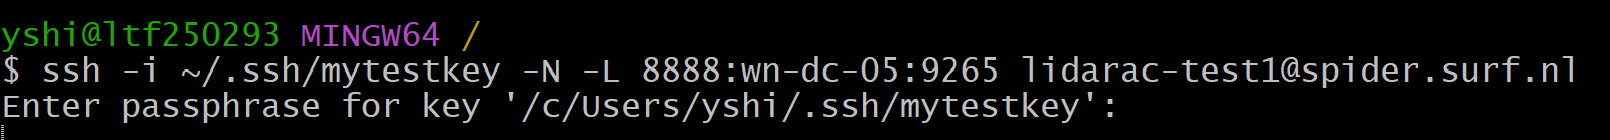

Now go to your browser, open a new window, and type in `localhost:8888`, then you will be directed to the log in page of the JupyterLab (for first time log in). You can find the token from the `.out` file in your terminal. Copy the token to your browser login page. Press Log in. 

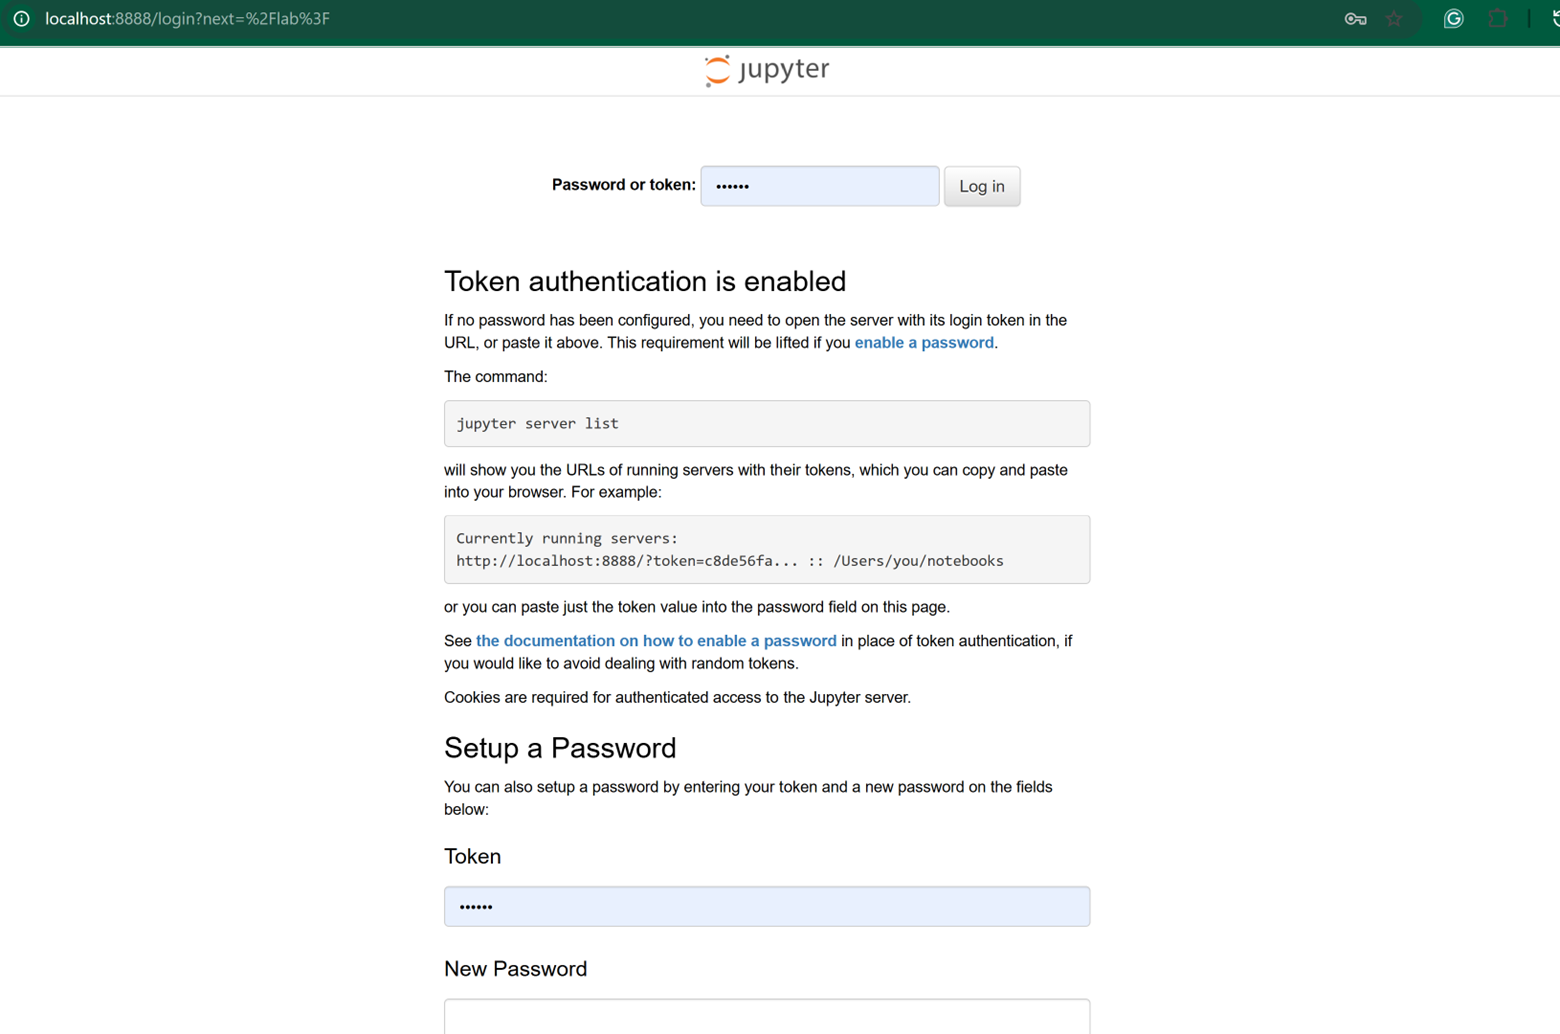

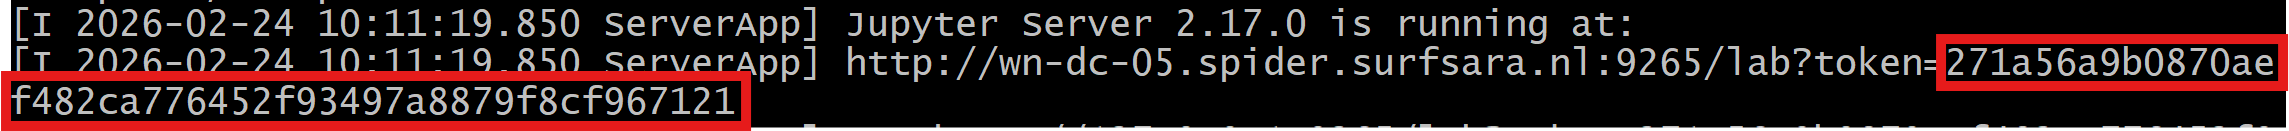

Then you will see the JupyterLab interface has been loaded, you can open the first jupyter notebook: `1_Retiling.ipynb`

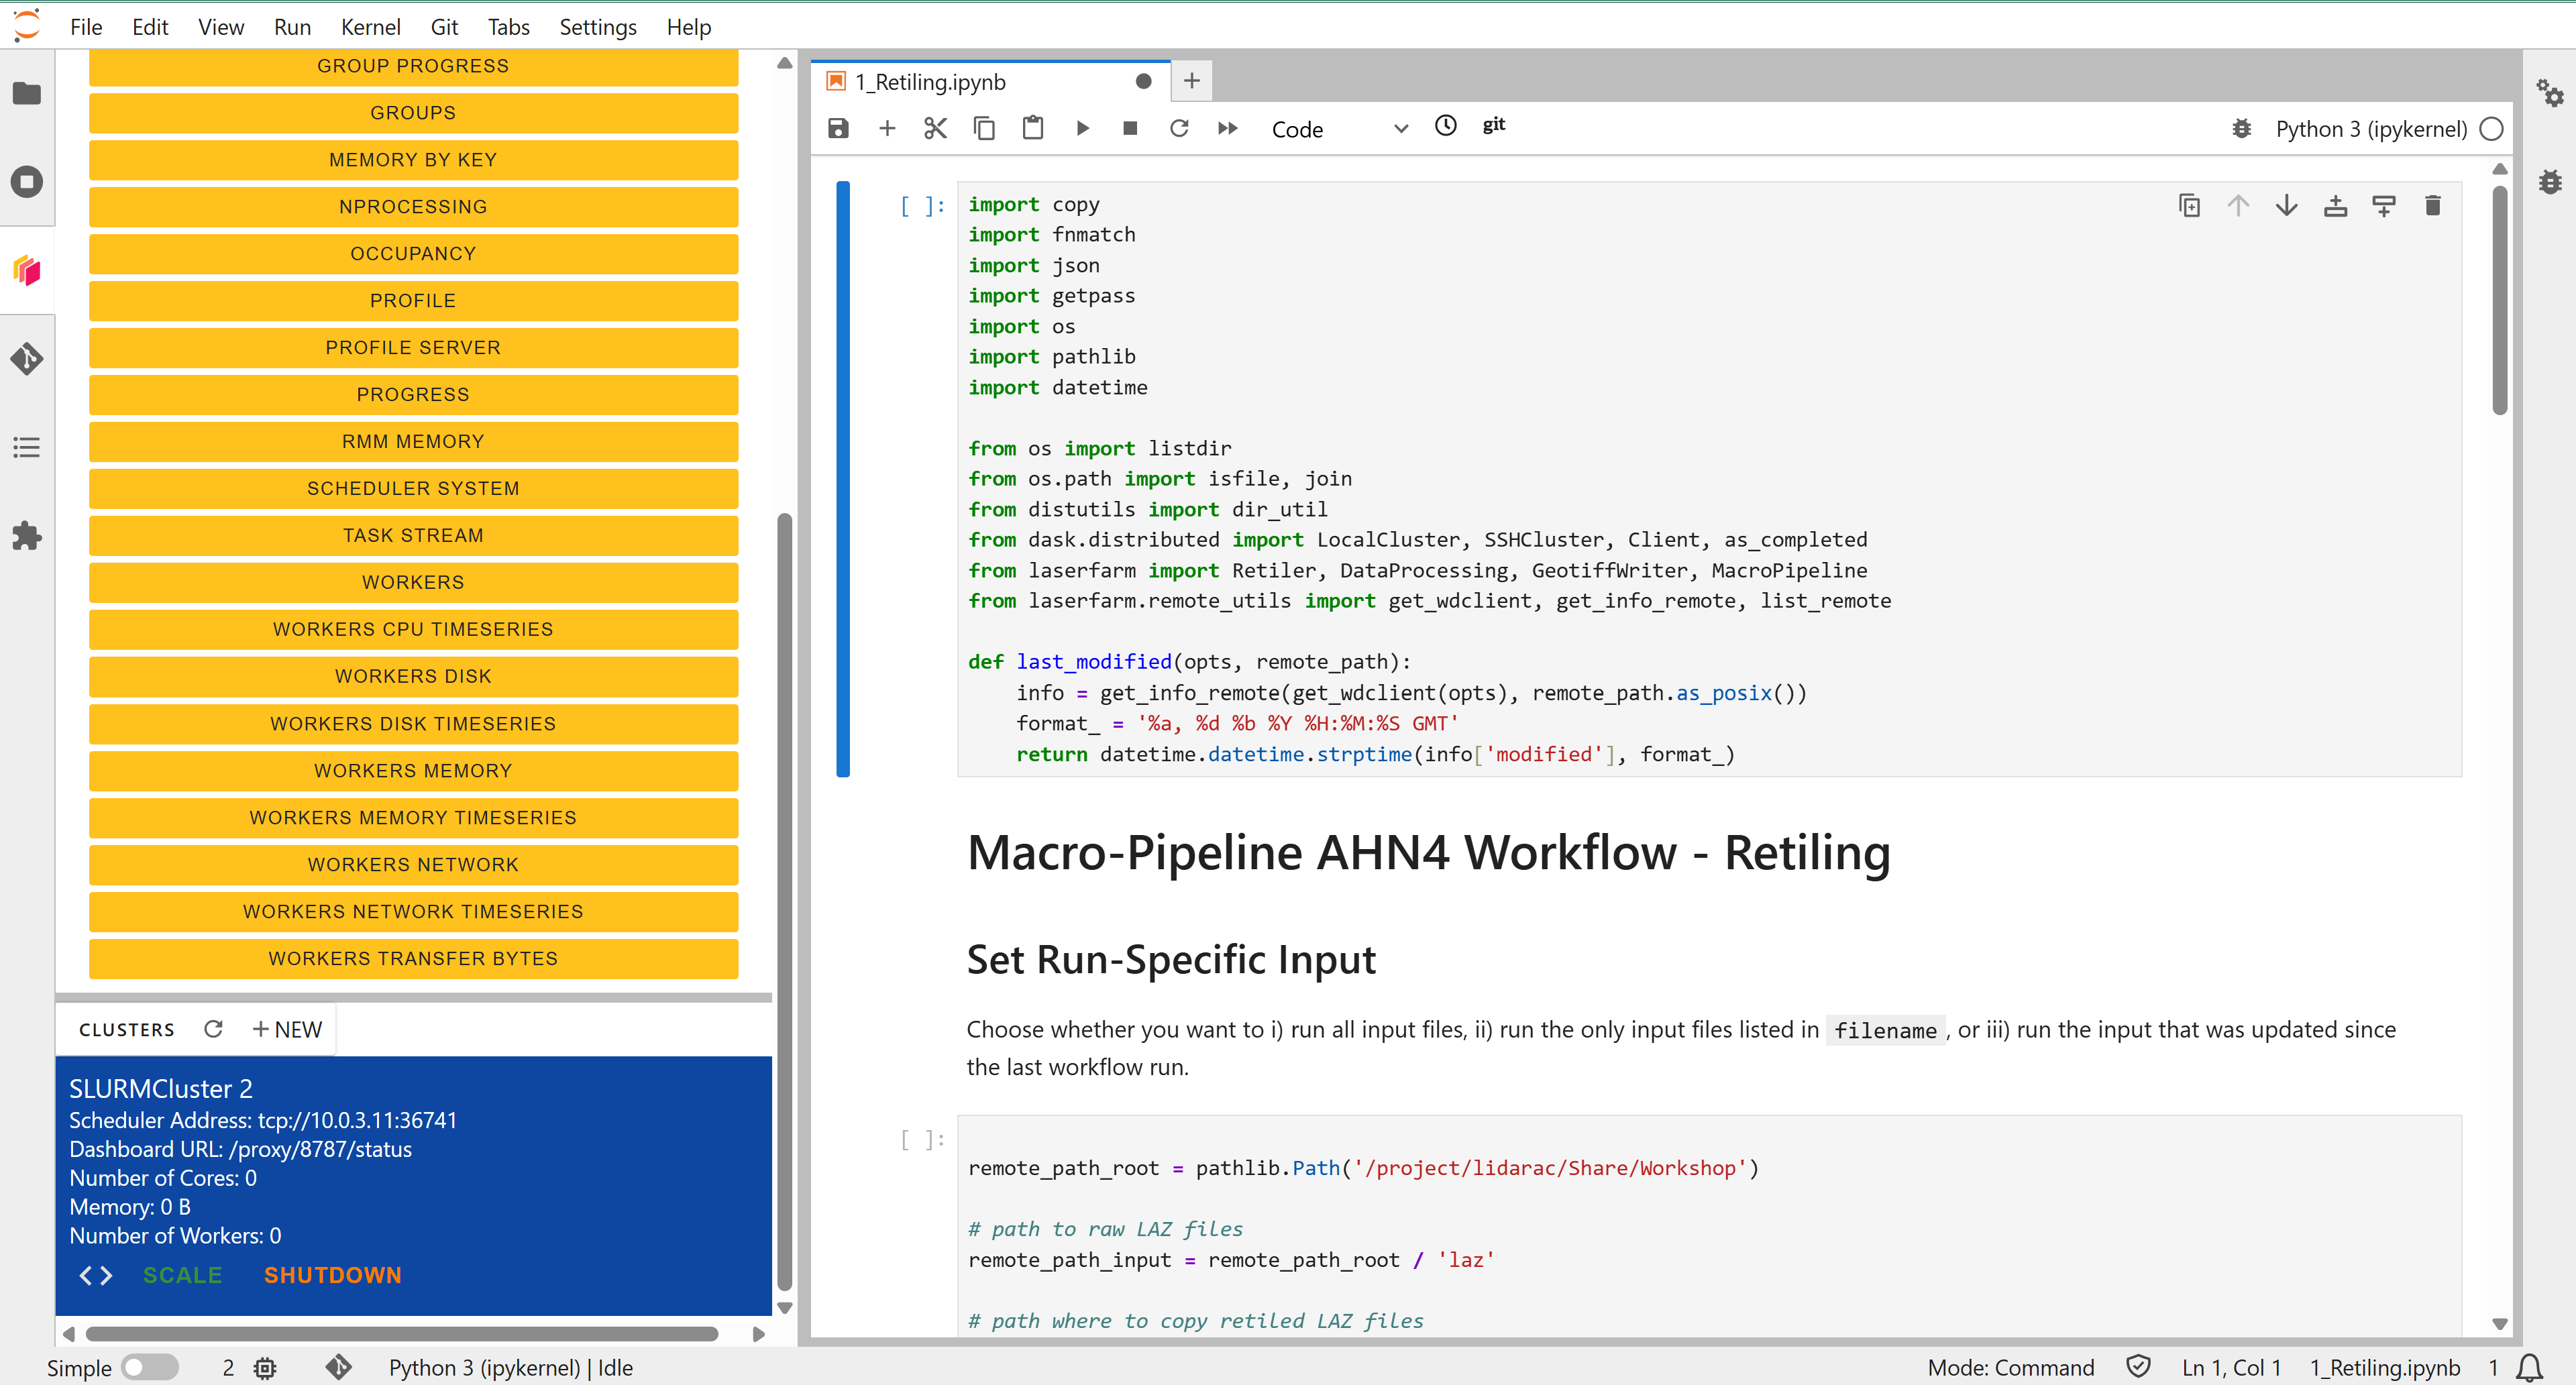

In the terminal, you can go to the folder containing the data prepared for this workshop by typing in:  

`cd /project/lidarac/Share/Workshop`  

List all the subfolders within the “Workshop” folder. Note that all the intermediate results and subfolders will be using this directory as well.   

`ls`  

Under folder “laz”, you will find all the test data we are going to process using Laserfarm workflow. 

Back to your browser where JupyterLab has opened. You can set up your workers by start a new cluster, and scale it to **`3`** workers. 


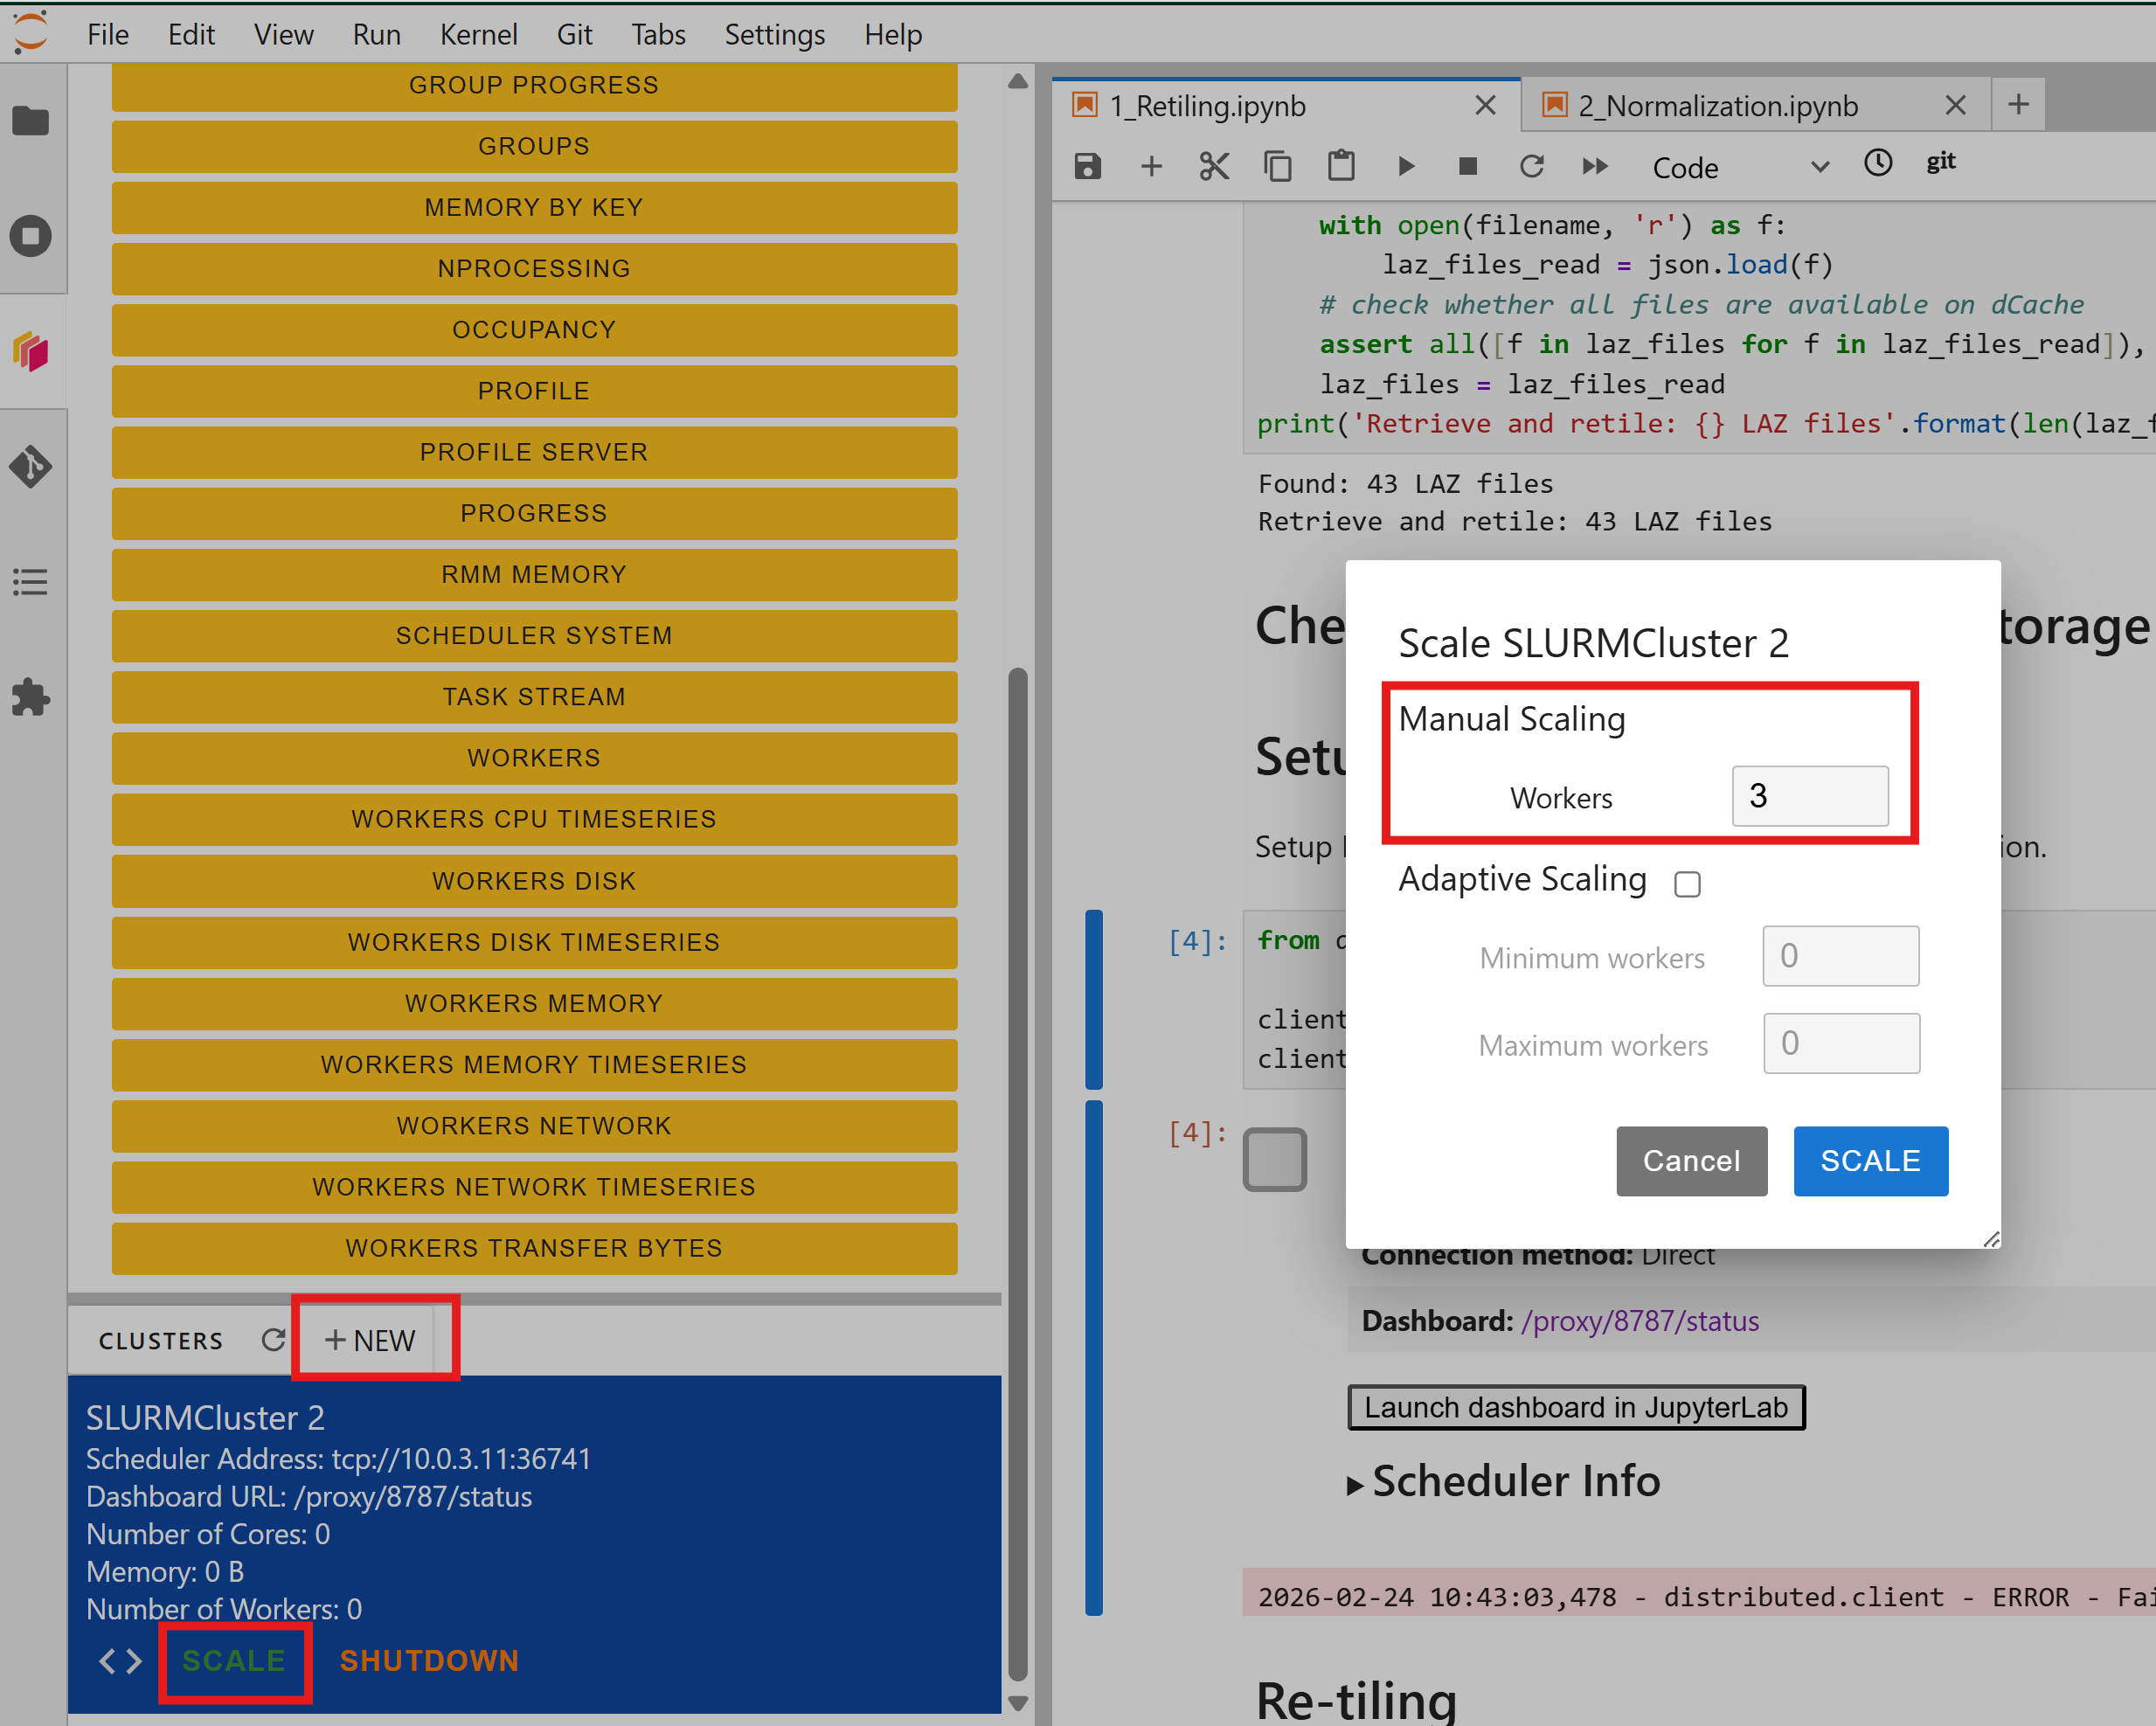

Once the workers have started, you can drag the cluster panel to your notebook, under session “Setup Cluster”.

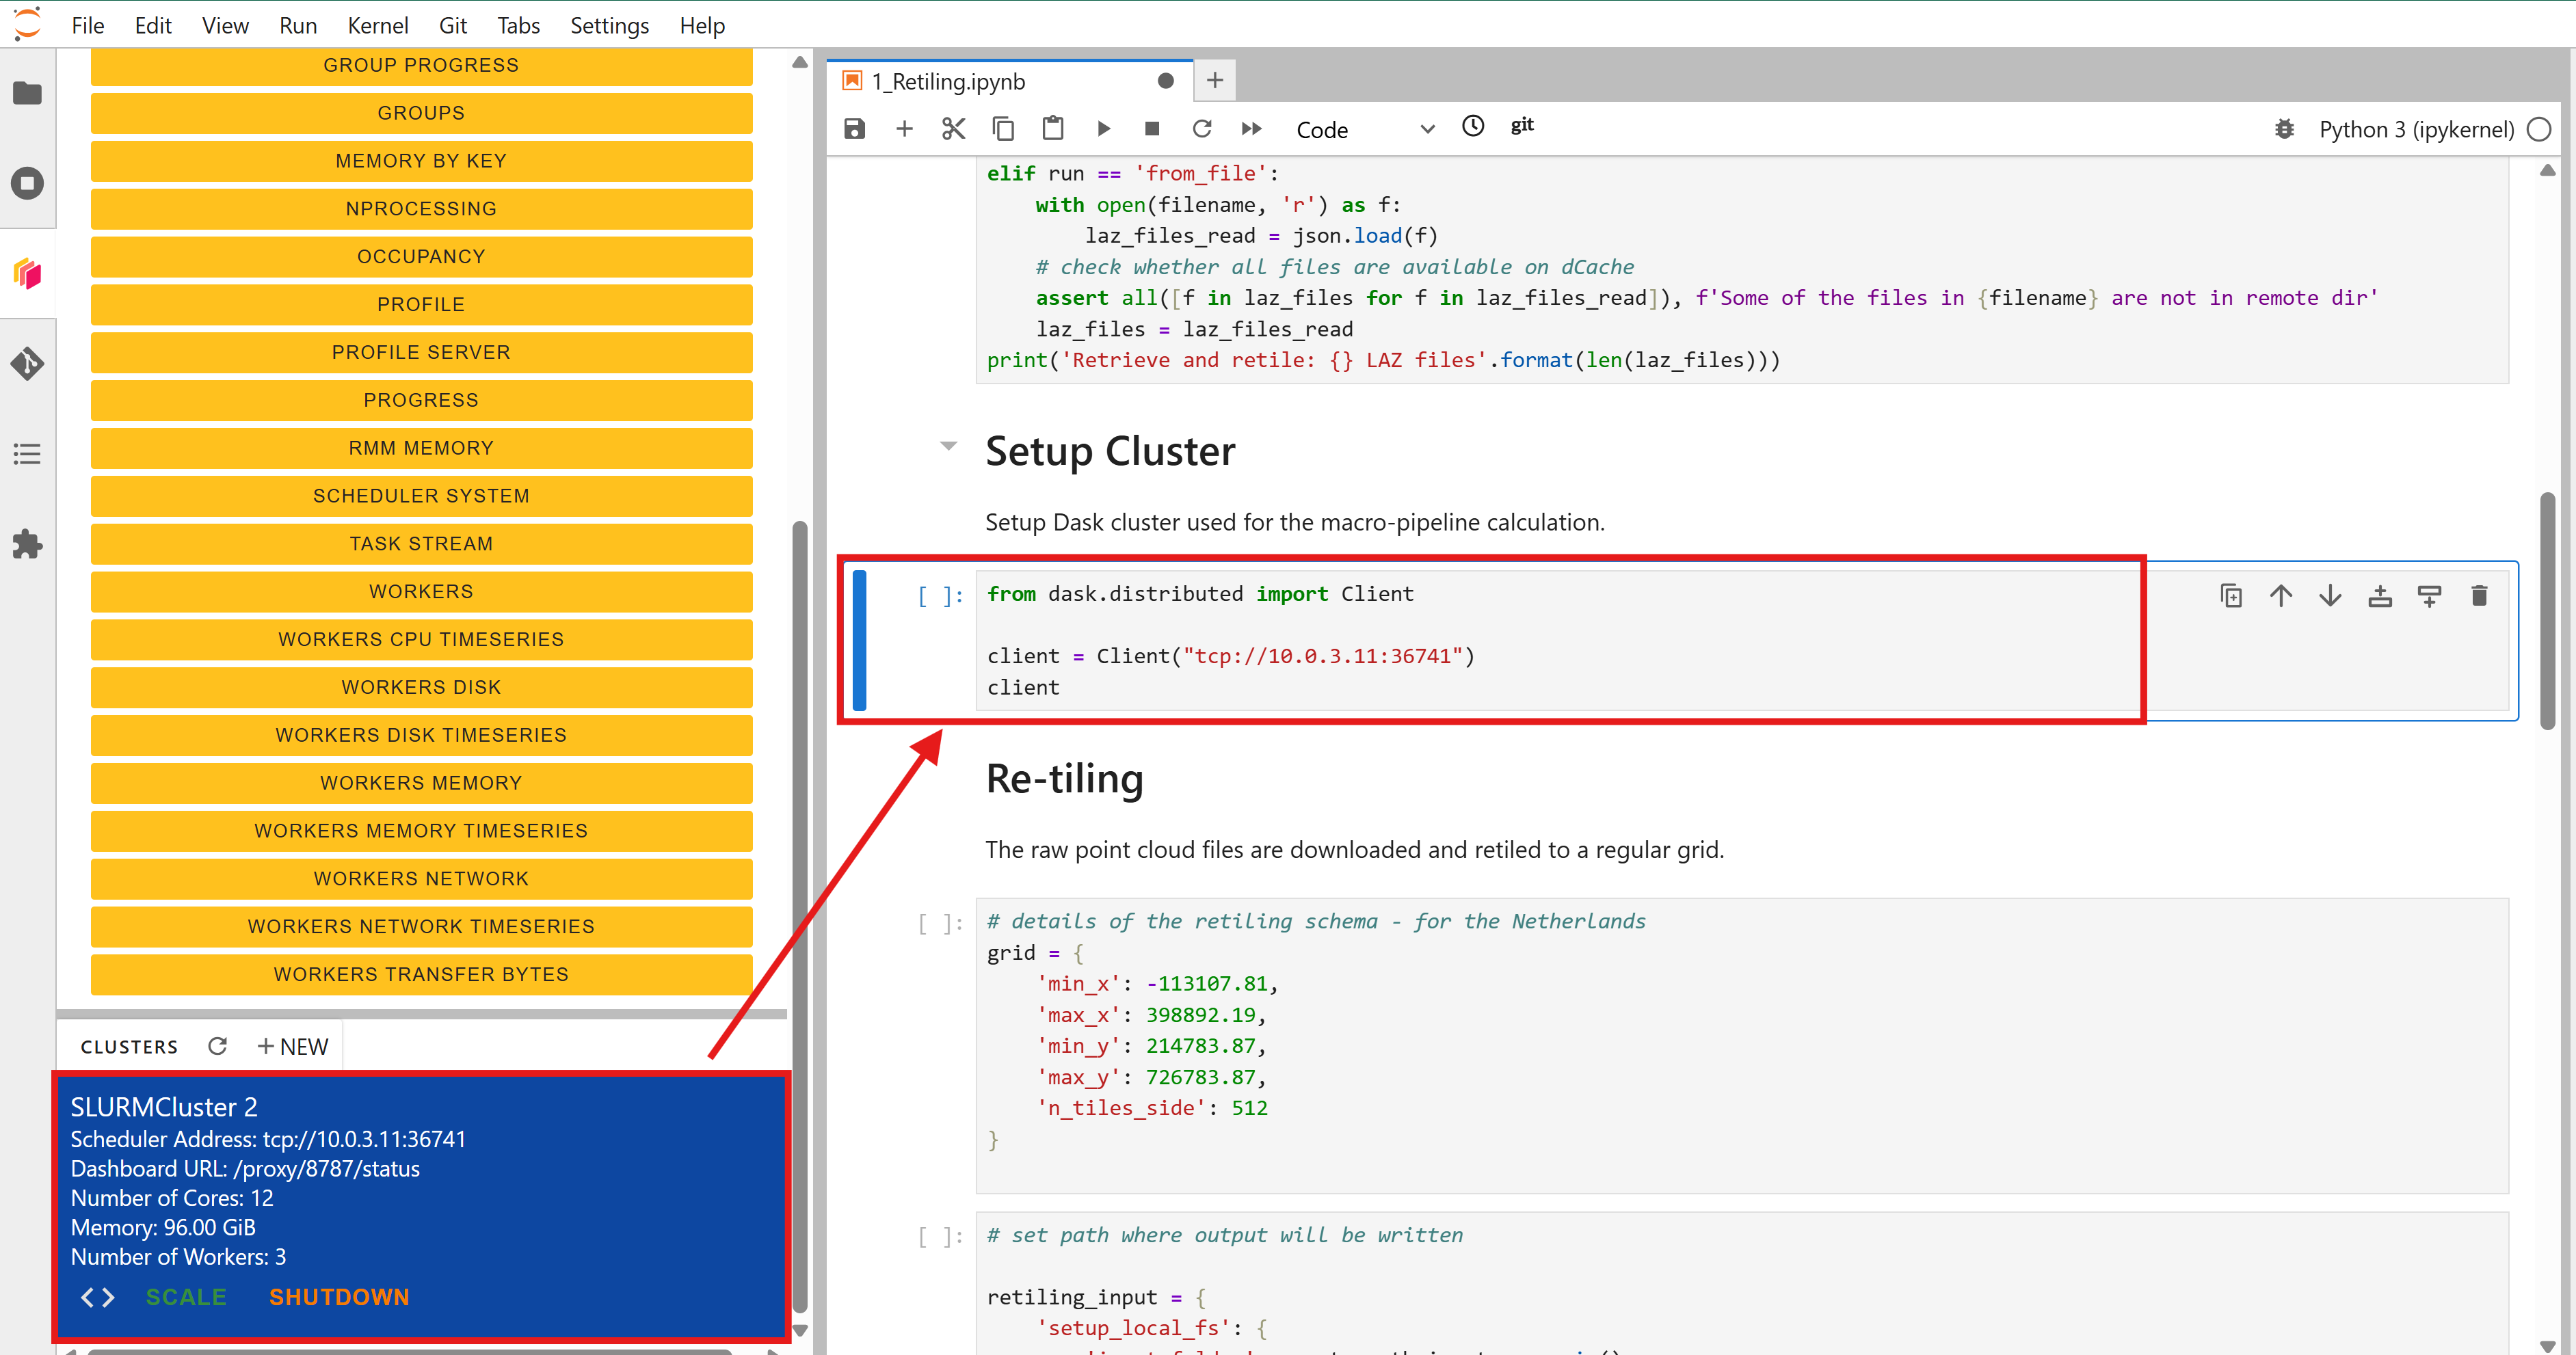

Copy the scheduler address (e.g. format like `"tcp://10.0.3.11:36741"`) into the cell of `MacroPipeline()`, under `macro.setup_cluster(cluster=" tcp://10.0.3.11:36741")`.

Now you are ready to run the workflow steps on SLURM using a cluster. You can also click the _Dashboard URL_ to visualize the process of the files among each worker. You can see the number of workers, the memory usage for each worker, and the files that have been successfully processed in yellow bars.  

As you can see in the cluster, we have assigned 12 cores for 3 workers (4 cores per worker, 12 GB memory for each core), that is why you can see 12 rows of yellow bars, meaning each core was handling one file and those files were processed by those 3 workers in parallel. **Note: for this workshop, we have reserved 3 workers with 12 cores in total for each participant. Given the number of participants and reserved resources, please only use maximam 3 workers during this hands-on session.**


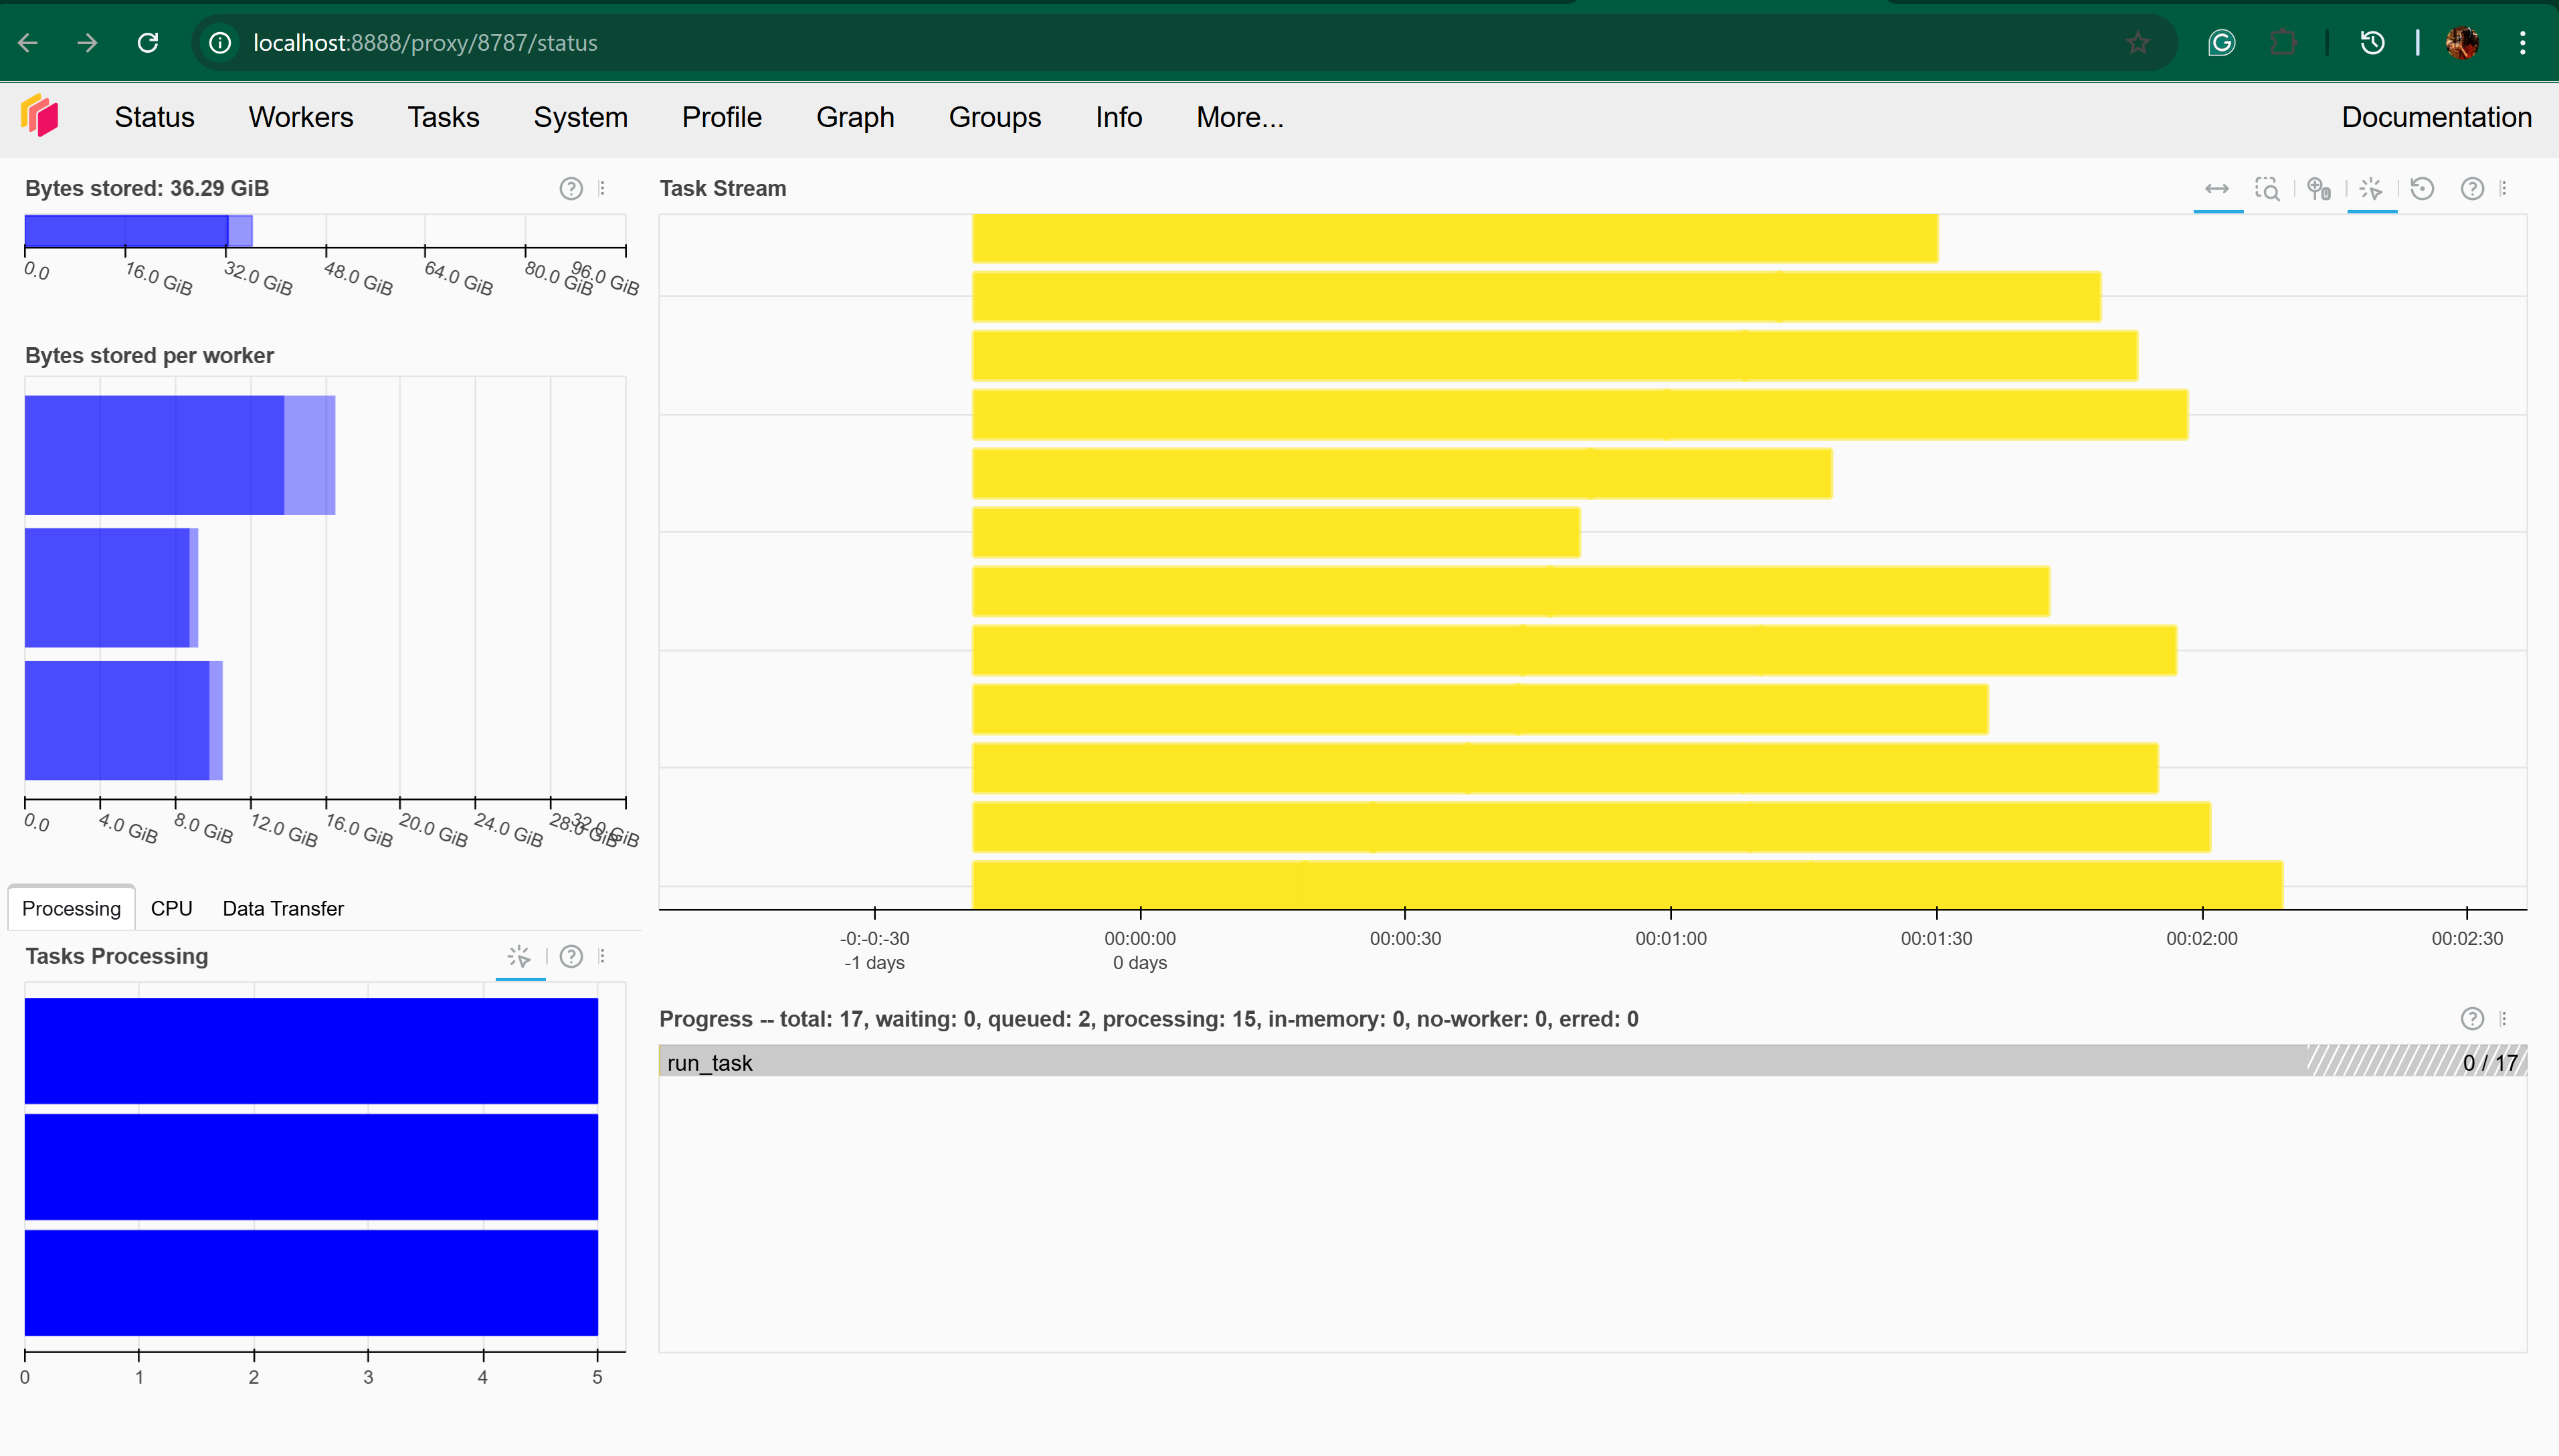

You can use the same cluster to run the rest of the steps with separate notebooks. 